# MemorySwap
### Which memory carries the chess position?

[Repository](https://github.com/eigengenesis/memoryswap) · [Protocol](https://github.com/eigengenesis/memoryswap/blob/main/docs/qwen35_chess_memory_plan.md) · [Artifacts](https://github.com/eigengenesis/memoryswap/releases/tag/v1.0)

**Frozen Qwen3.5-4B-Base** · 100 held-out pairs · Kaggle T4

A guided tour of the saved experiment. Read the figures below, or choose **Runtime → Run all** to download the compact release, check its hashes, and recompute the primary effects. A CPU runtime is enough; the notebook does not download the language model.

---

## 01 / The question

The model sees a sequence of chess moves, but no board. Which of its two memory systems carries information that affects its next-move preference?

I swapped recurrent states and attention key/value caches between matched games. A chess rules engine supplied the true positions and legal moves. Separately, I trained linear readouts to ask how much of the board could be recovered from the model's final query activation.

## 02 / What happened

**KV swaps moved behavior more strongly toward the donor. Recurrent erasure still reduced accuracy to chance.**

| Donor effect | Mean shift | 95% bootstrap interval |
| :--- | ---: | ---: |
| Recurrent | 0.35 nats | 0.19 to 0.52 |
| Attention KV | 3.51 nats | 2.96 to 4.08 |
| KV minus recurrent | **3.16 nats** | **2.60 to 3.71** |

A positive shift means greater relative probability for the donor position's legal move. These are saved results from the original evaluation; the cells below recompute the means from individual token scores. Crossed-cache board readouts mixed both donors, so the behavioral effect does not establish a complete board stored exclusively in KV.

### Load the saved run

This cell downloads the public v1.0 review bundle (about 18 MB). It contains the preserved experiment outputs and original figures. No account, file upload, GPU, or model download is needed.

In [1]:
from pathlib import Path
import tarfile
from urllib.request import urlretrieve

release_url = 'https://github.com/eigengenesis/memoryswap/releases/download/v1.0/qwen35_chess_memory_review_bundle.tar.gz'
workspace = Path('/content') if Path('/content').is_dir() else Path.cwd()
archive = workspace / 'qwen35_chess_memory_review_bundle.tar.gz'
urlretrieve(release_url, archive)
extract_root = workspace / 'qwen35_chess_review'
extract_root.mkdir(parents=True, exist_ok=True)
with tarfile.open(archive, 'r:gz') as tar:
    root = extract_root.resolve()
    for member in tar.getmembers():
        assert member.isfile() or member.isdir(), f'Unsupported archive entry: {member.name}'
        target = (extract_root / member.name).resolve()
        assert target == root or root in target.parents, f'Unsafe archive path: {member.name}'
    tar.extractall(extract_root)
RUN_DIR = extract_root / 'run'
assert (RUN_DIR / 'summary.json').is_file()
print('Saved run ready. No model was loaded.')

Saved run ready. No model was loaded.


In [2]:
# These values are also recomputed from raw token log-probabilities below.
print(SAVED_RESULT_SUMMARY if 'SAVED_RESULT_SUMMARY' in globals() else '''VERIFIED SAVED RESULTS
Model: Qwen/Qwen3.5-4B-Base
Primary held-out pairs: 100
Recurrent donor effect: 0.354 nats [0.195, 0.519]
KV donor effect: 3.511 nats [2.960, 4.077]
KV minus recurrent: 3.157 nats [2.603, 3.711]
Intact balanced candidate accuracy: 78.5% [73.5%, 83.0%]
Recurrent-zeroed accuracy: 49.5% [47.5%, 51.5%]
KV-zeroed accuracy: 55.5% [51.0%, 60.0%]
Intact changed-square readout: 61.0% [59.1%, 62.8%]
Orderless changed-square baseline: 53.0%
Exact 64-square recovery: 0.5%''')

VERIFIED SAVED RESULTS
Model: Qwen/Qwen3.5-4B-Base
Primary held-out pairs: 100
Recurrent donor effect: 0.354 nats [0.195, 0.519]
KV donor effect: 3.511 nats [2.960, 4.077]
KV minus recurrent: 3.157 nats [2.603, 3.711]
Intact balanced candidate accuracy: 78.5% [73.5%, 83.0%]
Recurrent-zeroed accuracy: 49.5% [47.5%, 51.5%]
KV-zeroed accuracy: 55.5% [51.0%, 60.0%]
Intact changed-square readout: 61.0% [59.1%, 62.8%]
Orderless changed-square baseline: 53.0%
Exact 64-square recovery: 0.5%


## 03 / Erase a memory channel

Both erasures damaged behavior and the linear readout. Dashed lines show the fixed-preference behavioral baseline and the strongest cheap readout baseline. Zeroing preserves cache shapes and positions; it does not remove the corresponding layers.

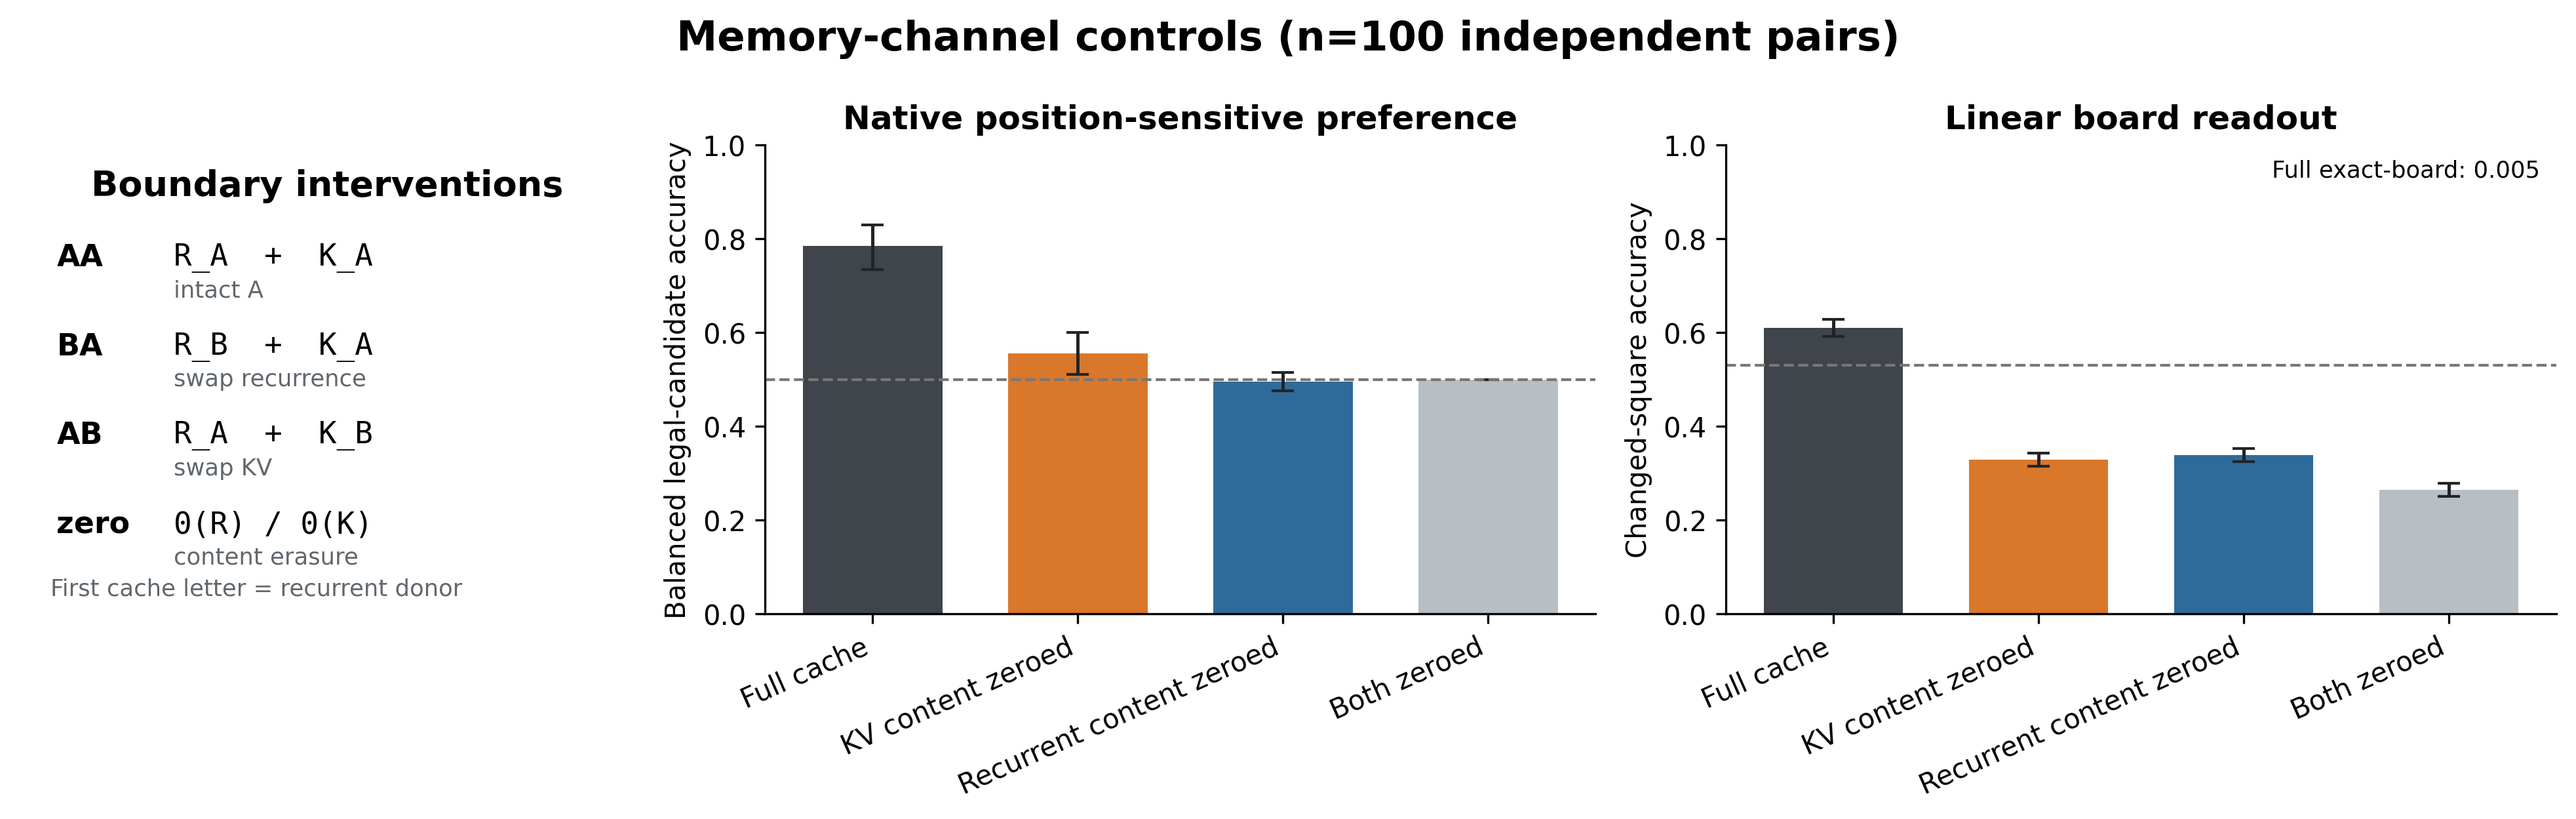

In [3]:
from IPython.display import display
from PIL import Image
display(Image.open(RUN_DIR / 'figures/01_memory_conditions.png'))

## 04 / Swap in another game's memory

KV donor changes caused the larger behavioral shift, while the crossed-cache readout remained mixed. The same-position behavioral result was 50% before and after swapping, so it cannot demonstrate preserved competent behavior.

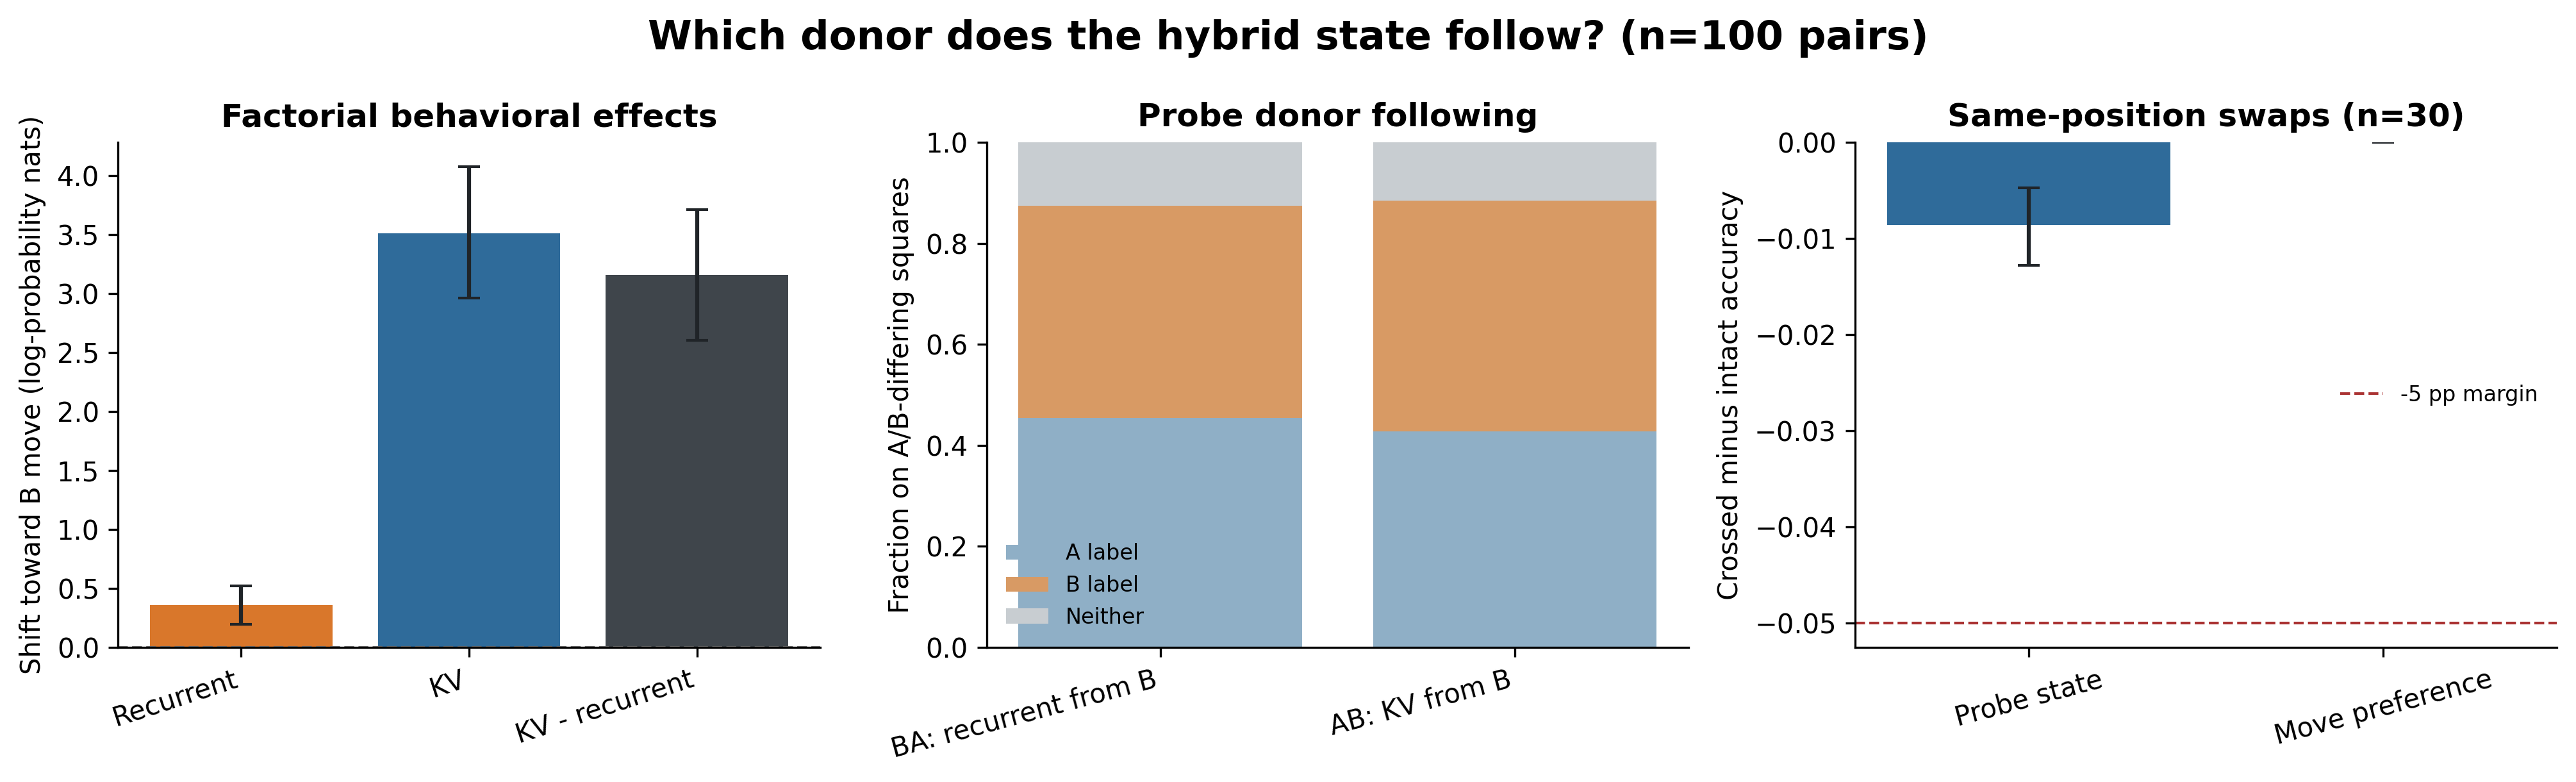

In [4]:
display(Image.open(RUN_DIR / 'figures/02_donor_following.png'))

## 05 / Play a few more moves

KV donor influence remained positive after one, two, and four additional plies. Both recurrent and attention layers processed those new tokens, so this does not localize the updating computation. Shading shows the saved paired cluster-bootstrap intervals.

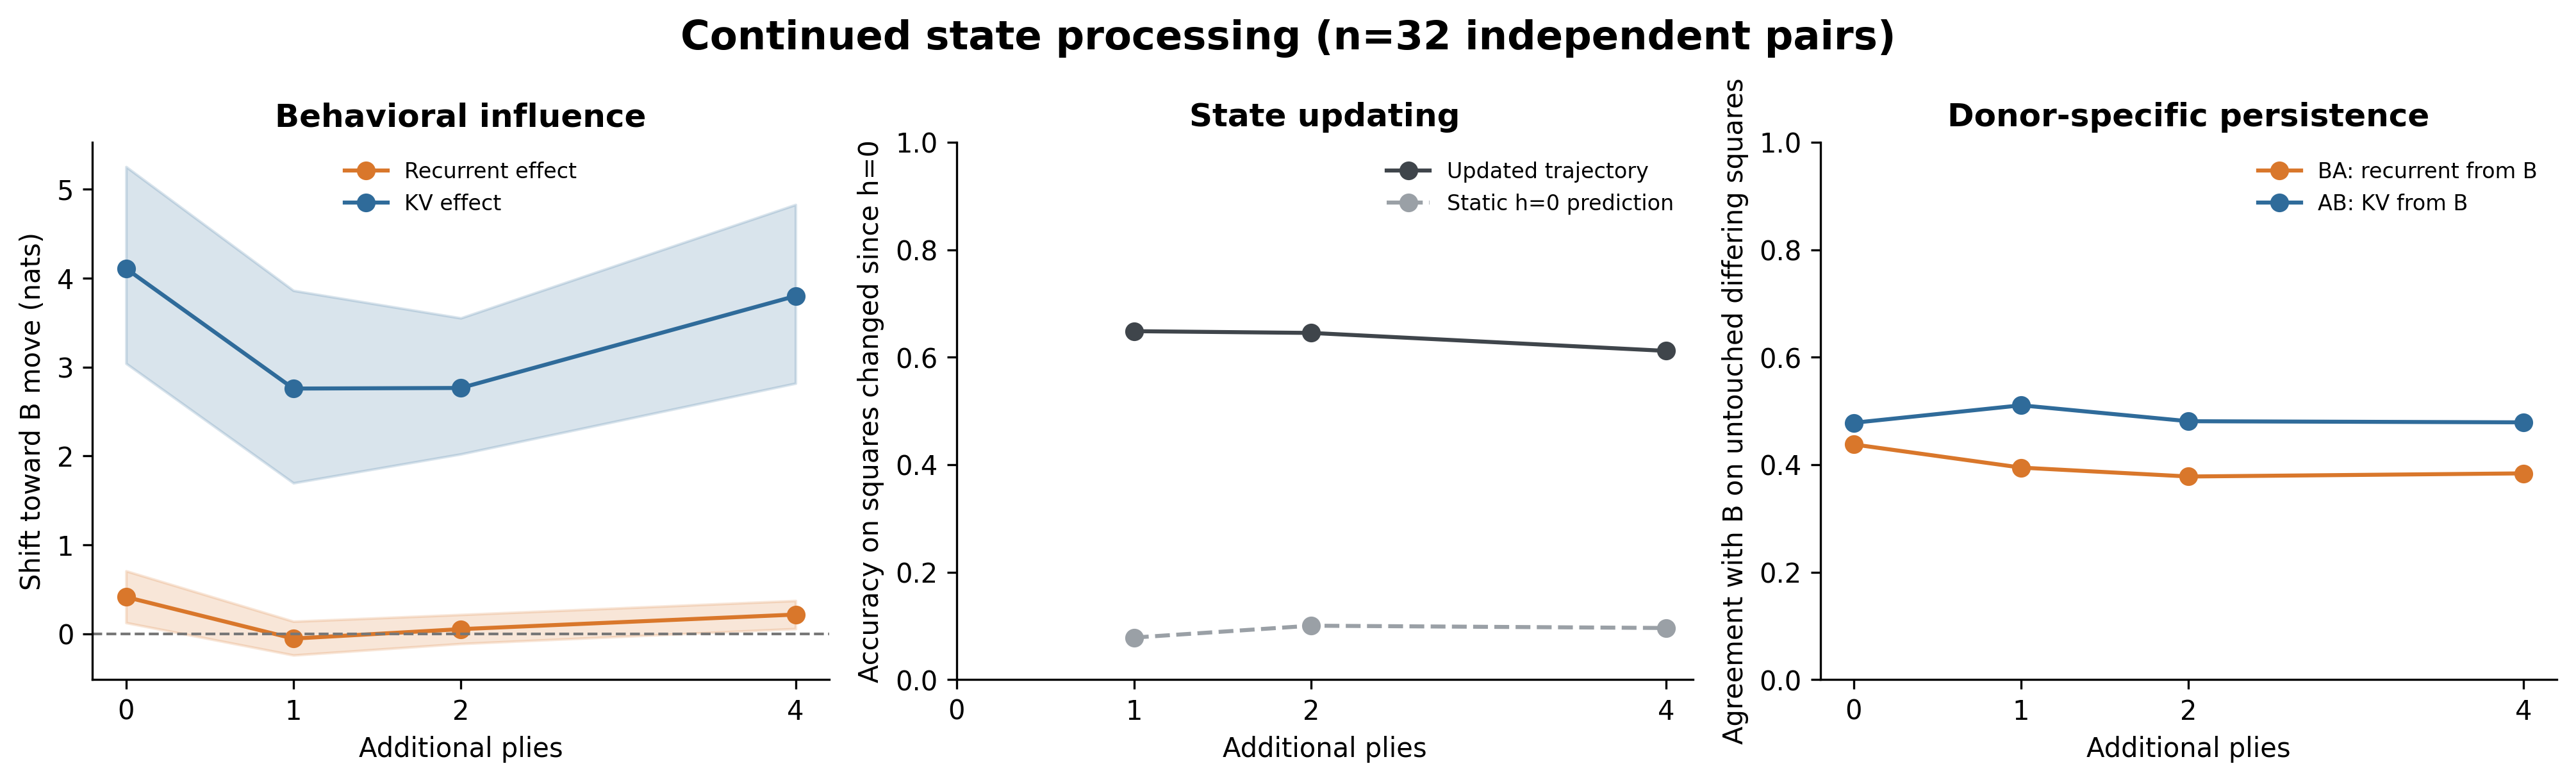

In [5]:
display(Image.open(RUN_DIR / 'figures/03_continuation.png'))

## 06 / How the comparison works

- Real January 2013 Lichess game histories were rendered as plain UCI move sequences. Board states and legality labels came from `python-chess` and were never provided to the model.
- Matched positions had equal ply count, tokenized history length, side to move, piece count, and check status.
- Each pair had move *a*, legal only in A, and move *b*, legal only in B. Candidate selection did not use model scores.
- `AA=(R_A,K_A)`, `BB=(R_B,K_B)`, `BA=(R_B,K_A)`, and `AB=(R_A,K_B)`.
- Candidate behavior used full-continuation log-probabilities. Linear ridge readouts predicted 64 square occupancies plus side to move, castling rights, and en-passant state.
- Intervals used 10,000 paired cluster-bootstrap samples. They measure variation across selected examples, not across models or independent experimental replications.

## 07 / Check the evidence

Compare included files with the original verification report. The compact bundle omits some arrays and feature files. The time log contains a later appended entry, so the check also recognizes its recorded prefix.

In [6]:
import hashlib, json

def sha256(path):
    h = hashlib.sha256()
    with path.open('rb') as handle:
        for block in iter(lambda: handle.read(1024 * 1024), b''):
            h.update(block)
    return h.hexdigest()

verification = json.loads((RUN_DIR / 'verification.json').read_text())
checked, missing, mismatched = [], [], []
for relative, expected in verification['artifact_hashes'].items():
    path = RUN_DIR / relative
    if not path.exists():
        missing.append(relative)
        continue
    actual = sha256(path)
    if actual != expected and relative == 'time_log.csv':
        lines = path.read_bytes().splitlines(keepends=True)
        actual = hashlib.sha256(b''.join(lines[:-1])).hexdigest()
    (checked if actual == expected else mismatched).append(relative)
for relative, expected in verification['figure_hashes'].items():
    path = RUN_DIR / 'figures' / relative
    if not path.exists():
        missing.append('figures/' + relative)
        continue
    (checked if sha256(path) == expected else mismatched).append('figures/' + relative)
assert not mismatched, mismatched
print(f'Hash-matched included files: {len(checked)}')
print(f'Files listed in the original report but absent from this compact bundle: {len(missing)}')
print('Result journals verified:', all(f'results/{n}.jsonl' in checked for n in ['primary','continuations','transpositions']))

Hash-matched included files: 30
Files listed in the original report but absent from this compact bundle: 4
Result journals verified: True


### Recompute the primary effects

Sum the saved token log-probabilities for each candidate move, then average each channel's effect across both settings of the other channel. This reproduces the point estimates; the intervals above come from the original bootstrap analysis.

In [7]:
import json, statistics

rows = [json.loads(line) for line in (RUN_DIR / 'results/primary.jsonl').read_text().splitlines()]
effects = {'recurrent': [], 'kv': [], 'kv_minus_recurrent': [], 'interaction': []}
for row in rows:
    d = {}
    for condition in ('AA', 'AB', 'BA', 'BB'):
        saved = row['conditions'][condition]
        a = sum(saved['a_candidate']['token_logprobs'])
        b = sum(saved['b_candidate']['token_logprobs'])
        d[condition] = b - a
    r = ((d['BA'] - d['AA']) + (d['BB'] - d['AB'])) / 2
    k = ((d['AB'] - d['AA']) + (d['BB'] - d['BA'])) / 2
    effects['recurrent'].append(r)
    effects['kv'].append(k)
    effects['kv_minus_recurrent'].append(k-r)
    effects['interaction'].append(d['BB']-d['BA']-d['AB']+d['AA'])
print('Rows:', len(rows))
for name, values in effects.items():
    print(f'{name}: {statistics.mean(values):.10f} nats')

Rows: 100
recurrent: 0.3542148348 nats
kv: 3.5110327568 nats
kv_minus_recurrent: 3.1568179220 nats
interaction: 0.0092002767 nats


## 08 / What remains unresolved

- Crossed-cache readouts mixed both donors, and intact exact-board recovery was only 0.5%.
- Recurrent erasure severely damaged behavior despite its smaller donor-swap effect. Zeroing may cause general disruption.
- Same-position behavioral accuracy was already at chance, limiting that control.
- Whole-channel transplantation creates potentially out-of-distribution states and cannot identify where information originated.
- The readout was trained on intact final-query activations, not directly on cache tensors, and was not shown to mediate behavior.
- This is one frozen checkpoint and one diagnostic chess distribution, not evidence about exclusive storage, optimal chess, or other domains.

### Run provenance

Run ID: `qwen4b-seed11-v1`  
Study ID: `qwen35-chess-memory-v1`  
Evaluated model revision: `1001bb4d826a52d1f399e183466143f4da7b741b`  
Protocol freeze SHA-256: `64f0c75b8ae0521e0a89c918e305bcdfdc3f48e8796a797c09c64a6675606619`  
The displayed figures are the original figures loaded from the release bundle and checked against the saved verification report. No model cache or model weights are included.

### Sources

- [Afendulev et al., What Attention Recalls and Recurrence Controls in Hybrid Language Models](https://arxiv.org/abs/2609.04434): methodological precedent for crossed recurrent/KV caches.
- [Qwen3.5-4B-Base model card](https://huggingface.co/Qwen/Qwen3.5-4B-Base).
- [Lichess open database](https://database.lichess.org/) and [`python-chess`](https://python-chess.readthedocs.io/).
- [Nanda, Actually, Othello-GPT Has A Linear Emergent World Representation](https://www.neelnanda.io/mechanistic-interpretability/othello).